# Explore Data

In [1]:
import pandas as pd
import yaml
from pathlib import Path

In [ ]:
# config_path = Path("../config.yaml")

# with open(config_path, encoding="utf-8") as f:
#         config = yaml.safe_load(f)

# data_cfg = config["data"]

In [ ]:
# data_cfg

{'dataset': 'US',
 'seq_len': 20,
 'num_workers': 2,
 'fit_start_time': '2009-01-01',
 'fit_end_time': '2017-12-31',
 'val_start_time': '2018-01-01',
 'val_end_time': '2018-12-31',
 'test_start_time': '2018-01-01',
 'test_end_time': '2018-06-30',
 'select_feature': None}

In [ ]:
# dataset = pd.read_pickle(Path("..") / data_cfg["dataset"]).iloc[:, :159]

In [6]:
dataset = pd.read_pickle("C:/Users/Nirawit EN/Downloads/VAE_PROJECT/Patt-Recog-2026-Project-Factor-Analysis-Using-VAE/data/csi_data.pkl")

In [7]:
dataset

KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2008-01-02 SH600000    0.562352  1.966025  0.233436  3.000000  0.947248   
           SH600004    3.000000  1.875718  1.424987 -0.633913 -0.918046   
           SH600006    0.692115  0.686199  0.451402  0.222079 -0.212134   
           SH600007    3.000000  3.000000  1.176976  0.198355 -0.679869   
           SH600008    2.864502  3.000000  0.914497  3.000000  0.400688   
...                         ...       ...       ...       ...       ...   
2020-09-23 SZ300413    0.416155  0.168837  0.345299  1.375385  1.078412   
           SZ300433    0.197337  0.608699  0.128362  1.541743  0.805404   
           SZ300498    0.113067 -1.022218  0.267531  0.388545  2.128231   
           SZ300601    3.000000  3.000000  1.252477  0.323448 -0.787971   
           SZ300628    0.070007 -0.504981  0.096319  1.293927  2.100165   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2008-01-02 SH600000    2.817562  0.658873  0.222092  0.095829 -0.556592  ...   
           SH600004   -1.071735 -1.078762  2.690770  1.189589 -3.000000  ...   
           SH600006    2.320270  1.218680  1.185791  0.775660 -0.683470  ...   
           SH600007    0.539353 -0.556108  3.000000  1.049928 -3.000000  ...   
           SH600008   -0.507849 -0.891697  1.299417  0.416317 -2.725143  ...   
...                         ...       ...       ...       ...       ...  ...   
2020-09-23 SZ300413    0.384109  0.167192  0.022887  0.018917 -0.412950  ...   
           SZ300433    2.102757  1.140706  0.265099  0.179002 -0.196575  ...   
           SZ300498   -0.904586 -0.714966 -0.283859 -0.596669 -0.112797  ...   
           SZ300601    0.780048 -0.677035  3.000000  1.113316 -3.000000  ...   
           SZ300628   -0.357260 -0.147672 -0.461006 -0.580212 -0.069892  ...   

                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5  \
datetime   instrument                                                     
2008-01-02 SH600000    0.489803 -0.248700 -0.465013  0.406620 -0.008655   
           SH600004   -1.919014 -2.186280 -2.172815  0.629618  1.820745   
           SH600006    0.187804 -1.378459 -0.228292  1.114946 -0.125054   
           SH600007   -2.856316 -3.000000 -3.000000 -3.000000  2.503788   
           SH600008   -0.867261 -2.393089 -2.820308 -1.557023  1.400840   
...                         ...       ...       ...       ...       ...   
2020-09-23 SZ300413    2.161954  2.722763  1.238667  1.115238 -0.046240   
           SZ300433    1.871413  2.230483  0.787715  0.737561 -1.071765   
           SZ300498    3.000000  1.050971  0.619927  1.057896 -0.994338   
           SZ300601    0.910483 -1.216829  0.208075 -1.424633  2.337248   
           SZ300628    0.808702  0.257942  0.384812  0.774238 -0.013999   

                        VSUMD10   VSUMD20   VSUMD30   VSUMD60  \
datetime   instrument                                           
2008-01-02 SH600000   -0.489803  0.248700  0.465014 -0.406619   
           SH600004    1.919015  2.186279  2.172818 -0.629617   
           SH600006   -0.187805  1.378459  0.228293 -1.114945   
           SH600007    2.856318  3.000000  3.000000  3.000000   
           SH600008    0.867262  2.393089  2.820312  1.557021   
...                         ...       ...       ...       ...   
2020-09-23 SZ300413   -2.161956 -2.722761 -1.238668 -1.115237   
           SZ300433   -1.871415 -2.230482 -0.787715 -0.737561   
           SZ300498   -3.000000 -1.050970 -0.619927 -1.057894   
           SZ300601   -0.910484  1.216828 -0.208073  1.424631   
           SZ300628   -0.808704 -0.257941 -0.384811 -0.774236   

                       Ref($close, -2)/Ref($close, -1) - 1  
datetime   instrument                                       
2008-01-02 SH600000                               1.228519  
     

In [ ]:
# dataset.to_parquet("sp500dataset.parquet")

# MODULE

In [8]:
from scipy.stats import spearmanr


def compute_metrics(df, pred_col="score", target_col="LABEL0"):
    """
    Rank IC, ICIR, and precision@10% (FactorVAE-style).
    Assumes df has a MultiIndex (datetime, instrument).
    """

    def daily_rank_ic(group):
        return spearmanr(group[pred_col], group[target_col])[0]

    daily_ic = df.groupby(level="datetime").apply(daily_rank_ic)

    rank_ic_mean = daily_ic.mean()
    rank_ic_std = daily_ic.std()
    icir = rank_ic_mean / rank_ic_std if rank_ic_std != 0 else 0

    def daily_precision(group, k=0.1):
        n = len(group)
        top_k = int(n * k)
        if top_k == 0:
            return 0

        top_pred = group.nlargest(top_k, pred_col).index
        top_true = group.nlargest(top_k, target_col).index
        return len(set(top_pred) & set(top_true)) / top_k

    precision_at_10 = df.groupby(level="datetime").apply(daily_precision).mean()

    return {
        "Rank IC": rank_ic_mean,
        "Rank ICIR": icir,
        "Precision@10%": precision_at_10,
        "IC_Series": daily_ic,
    }


# MOVING AVERAGE

In [17]:
import pandas as pd
import numpy as np

# 1. Sort the MultiIndex 
df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

# 2. Define the Target Column
target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
pred_col = 'prediction_MA'

# 3. Create the Moving Average Baseline Prediction
window_size = 30
df[pred_col] = df.groupby(level='instrument')[target_col].transform(
    lambda x: x.shift(1).rolling(window=window_size).mean()
)

# 4. Filter for the Test Period
test_start = "2019-01-01"
test_end = "2019-12-31"

# Slice based on the 'datetime' level of your MultiIndex
test_df = df.loc[(df.index.get_level_values('datetime') >= test_start) & 
                 (df.index.get_level_values('datetime') <= test_end)].copy()

# Drop rows with NaN values in predictions or targets 
test_df = test_df.dropna(subset=[target_col, pred_col])

# 5. Evaluate using your custom function
# (Assuming compute_metrics is already defined in your environment)
ma_metrics = compute_metrics(
    df=test_df, 
    pred_col=pred_col, 
    target_col=target_col
)

# 6. Output the Results
print("\n" + "="*50)
print(f" MOVING AVERAGE ({window_size}-DAY) BASELINE RESULTS")
print(f" Test Period: {test_start} to {test_end}")
print("="*50)

for metric_name, value in ma_metrics.items():
    if metric_name != "IC_Series":  # Hide the daily series data from the printout
        print(f" {metric_name:<15}: {value:.5f}")
print("="*50)


 MOVING AVERAGE (30-DAY) BASELINE RESULTS
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : -0.02707
 Rank ICIR      : -0.16256
 Precision@10%  : 0.17213


# LGBM

Training LightGBM Model with Train/Val Split...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.170919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32710
[LightGBM] [Info] Number of data points in the train set: 608430, number of used features: 157
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 30 rounds
[10]	Train's l2: 0.993703	Validation's l2: 0.994896
[20]	Train's l2: 0.991962	Validation's l2: 0.994228
[30]	Train's l2: 0.990651	Validation's l2: 0.993822
[40]	Train's l2: 0.989618	Validation's l2: 0.993285
[50]	Train's l2: 0.988706	Validation's l2: 0.99294
[60]	Train's l2: 0.987903	Validation's l2: 0.992832
[70]	Train's l2: 0.987165	Validation's l2: 0.992742
[80]	Train's l2: 0.986478	Validation's l2: 0.992585
[90]	Train's l2: 0.985841	Validation's l2: 0.992401
[100]	Train's l2: 0.985213	Validation's l2: 0.992411
[110]	Train's l2: 0.984617

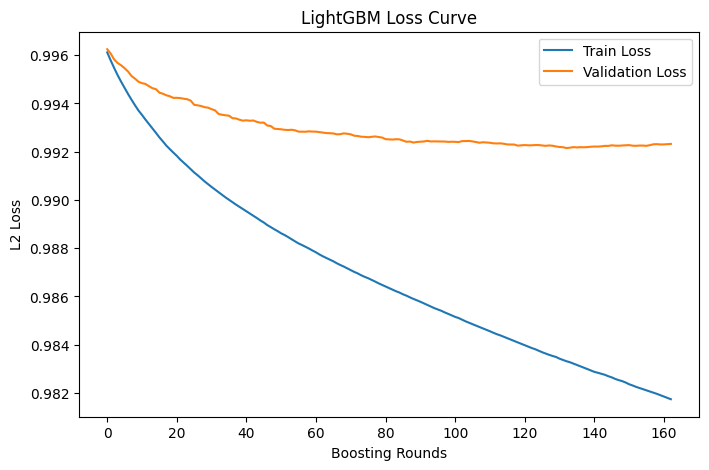

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20']
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features)

fit_start, fit_end = "2009-01-01", "2017-12-31"
val_start, val_end = "2018-01-01", "2018-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

dates = df_clean.index.get_level_values('datetime')

train_df = df_clean.loc[(dates >= fit_start) & (dates <= fit_end)].copy()
val_df = df_clean.loc[(dates >= val_start) & (dates <= val_end)].copy()
test_df = df_clean.loc[(dates >= test_start) & (dates <= test_end)].copy()

X_train, y_train = train_df[features], train_df[target_col]
X_val, y_val = val_df[features], val_df[target_col]
X_test, y_test = test_df[features], test_df[target_col]

print("Training LightGBM Model with Train/Val Split...")
model = lgb.LGBMRegressor(
    n_estimators=1000,       
    learning_rate=0.05, 
    num_leaves=15, 
    min_child_samples=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Validation'],
    eval_metric='l2',
    callbacks=[
        early_stopping(stopping_rounds=30),
        log_evaluation(period=10)
    ]
)

test_df['prediction_LGBM'] = model.predict(X_test)

lgbm_metrics = compute_metrics(
    df=test_df, 
    pred_col='prediction_LGBM', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LIGHTGBM TEST RESULTS (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in lgbm_metrics.items():
    if metric_name != "IC_Series":  # ซ่อนรายวันไว้ก่อนเพื่อความสะอาดของ Output
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)

evals_result = model.evals_result_
plt.figure(figsize=(8, 5))
plt.plot(evals_result['Train']['l2'], label='Train Loss')
plt.plot(evals_result['Validation']['l2'], label='Validation Loss')
plt.title('LightGBM Loss Curve')
plt.xlabel('Boosting Rounds')
plt.ylabel('L2 Loss')
plt.legend()
plt.show()

# LINEAR

In [11]:
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20', 'prediction_LGBM'] 
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features).copy()

fit_start, fit_end = "2009-01-01", "2017-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

dates = df_clean.index.get_level_values('datetime')

train_mask = (dates >= fit_start) & (dates <= fit_end)
test_mask = (dates >= test_start) & (dates <= test_end)

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, target_col]

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, target_col]

print("Training Linear Model (Ridge Regression)...")
linear_model = Ridge(alpha=1.0, random_state=42)
linear_model.fit(X_train, y_train)

df_clean.loc[test_mask, 'prediction_Linear'] = linear_model.predict(X_test)

test_df_for_eval = df_clean[test_mask].copy()

linear_metrics = compute_metrics(
    df=test_df_for_eval, 
    pred_col='prediction_Linear', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LINEAR Baseline Results (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in linear_metrics.items():
    if metric_name != "IC_Series": # ซ่อนรายวันไว้ก่อน
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)

Training Linear Model (Ridge Regression)...

 LINEAR Baseline Results (Out-of-Sample)
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : 0.02963
 Rank ICIR      : 0.22228
 Precision@10%  : 0.12181


# LSTM

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm

df = dataset.copy()
df = df.sort_index(level=['instrument', 'datetime'])

target_col = 'Ref($close, -2)/Ref($close, -1) - 1'
exclude_cols = [target_col, 'prediction_MA20', 'prediction_LGBM', 'prediction_Linear']
features = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=[target_col] + features).copy()

SEQ_LEN = 20 

def create_3d_sequences(df_group):
    """ฟังก์ชันสไลด์หน้าต่างข้อมูลทีละ 20 วัน สำหรับแต่ละหุ้น"""
    X_vals = df_group[features].values
    y_vals = df_group[target_col].values
    dates = df_group.index.get_level_values('datetime')
    
    X_seq, y_seq, seq_dates = [], [], []
    
    if len(X_vals) < SEQ_LEN:
        return None, None, None
        
    for i in range(len(X_vals) - SEQ_LEN + 1):
        X_seq.append(X_vals[i : i + SEQ_LEN])
        y_seq.append(y_vals[i + SEQ_LEN - 1])
        seq_dates.append(dates[i + SEQ_LEN - 1])
        
    return np.array(X_seq), np.array(y_seq), seq_dates

print(f"Generating 3D Sequences (T={SEQ_LEN}). This may take a moment...")
X_all, y_all, dates_all, instruments_all = [], [], [], []

for instrument, group in tqdm(df_clean.groupby(level='instrument')):
    X_seq, y_seq, val_dates = create_3d_sequences(group)
    if X_seq is not None:
        X_all.append(X_seq)
        y_all.append(y_seq)
        dates_all.extend(val_dates)
        instruments_all.extend([instrument] * len(val_dates))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
dates_all = np.array(dates_all)

Generating 3D Sequences (T=20). This may take a moment...


100%|██████████| 682/682 [00:22<00:00, 30.06it/s]


In [13]:
# ==========================================
# 3. แบ่ง Train, Val, Test (ตาม Timeline)
# ==========================================
dates_all = pd.to_datetime(dates_all)

fit_start, fit_end = "2009-01-01", "2017-12-31"
val_start, val_end = "2018-01-01", "2018-12-31"
test_start, test_end = "2019-01-01", "2019-12-31"

train_mask = (dates_all >= fit_start) & (dates_all <= fit_end)
val_mask = (dates_all >= val_start) & (dates_all <= val_end)
test_mask = (dates_all >= test_start) & (dates_all <= test_end)

def create_dataloader(X, y, batch_size=512, shuffle=False):
    tensor_x = torch.tensor(X, dtype=torch.float32)
    tensor_y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(X_all[train_mask], y_all[train_mask], batch_size=4096, shuffle=True)
val_loader = create_dataloader(X_all[val_mask], y_all[val_mask], batch_size=4096, shuffle=False)
test_loader = create_dataloader(X_all[test_mask], y_all[test_mask], batch_size=4096, shuffle=False)

In [14]:
# ==========================================
# 4. สร้างสถาปัตยกรรม LSTM
# ==========================================
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, 
                            hidden_size=hidden_size, 
                            num_layers=num_layers, 
                            batch_first=True, 
                            dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        predictions = self.linear(last_time_step)
        return predictions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = LSTMModel(
    input_size=len(features), 
    hidden_size=32,    
    num_layers=1       
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# ==========================================
# 5. Training Loop + Early Stopping
# ==========================================
epochs = 10
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0

print("Training LSTM Model...")
for epoch in range(epochs):
    
    print(f"Current Epoch : {epoch}")
    
    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item() * inputs.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1:02d} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered!")
            break


Using device: cuda


c:\Users\Nirawit EN\anaconda3\envs\Ai\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Training LSTM Model...
Current Epoch : 0
Epoch 01 | Val Loss: 0.992987
Current Epoch : 1
Epoch 02 | Val Loss: 0.994097
Current Epoch : 2
Epoch 03 | Val Loss: 0.995516
Current Epoch : 3
Epoch 04 | Val Loss: 0.994896
Current Epoch : 4
Epoch 05 | Val Loss: 0.998652
Current Epoch : 5
Epoch 06 | Val Loss: 0.999454
Early stopping triggered!


In [15]:
# ==========================================
# 6. Evaluation (ใช้ compute_metrics)
# ==========================================
model.load_state_dict(torch.load('best_lstm_model.pth', weights_only=True))
model.eval()

predictions = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions.extend(outputs.cpu().numpy().flatten())

idx_test = pd.MultiIndex.from_arrays(
    [dates_all[test_mask], np.array(instruments_all)[test_mask]], 
    names=['datetime', 'instrument']
)
test_df_eval = pd.DataFrame({
    target_col: y_all[test_mask],
    'prediction_LSTM': predictions
}, index=idx_test)

test_df_eval = test_df_eval[~test_df_eval.index.duplicated(keep='last')]

lstm_metrics = compute_metrics(
    df=test_df_eval, 
    pred_col='prediction_LSTM', 
    target_col=target_col
)

print("\n" + "="*45)
print(f" LSTM TEST RESULTS (Out-of-Sample)")
print(f" Test Period: {test_start} to {test_end}")
print("="*45)
for metric_name, value in lstm_metrics.items():
    if metric_name != "IC_Series":
        print(f" {metric_name:<15}: {value:.5f}")
print("="*45)


 LSTM TEST RESULTS (Out-of-Sample)
 Test Period: 2019-01-01 to 2019-12-31
 Rank IC        : 0.03675
 Rank ICIR      : 0.29717
 Precision@10%  : 0.12432


# SUMMARY

In [18]:
import pandas as pd
from IPython.display import display

results_data = [
    {"Model": "Moving Average",
     "Rank IC": ma_metrics["Rank IC"],
     "Rank ICIR": ma_metrics["Rank ICIR"],
     "Precision@10%": ma_metrics["Precision@10%"]},
     
    {"Model": "Linear (Ridge)",
     "Rank IC": linear_metrics["Rank IC"],
     "Rank ICIR": linear_metrics["Rank ICIR"],
     "Precision@10%": linear_metrics["Precision@10%"]},
     
    {"Model": "LSTM",
     "Rank IC": lstm_metrics["Rank IC"],
     "Rank ICIR": lstm_metrics["Rank ICIR"],
     "Precision@10%": lstm_metrics["Precision@10%"]},
     
    {"Model": "LightGBM",
     "Rank IC": lgbm_metrics["Rank IC"],
     "Rank ICIR": lgbm_metrics["Rank ICIR"],
     "Precision@10%": lgbm_metrics["Precision@10%"]}
]

results_df = pd.DataFrame(results_data).set_index("Model")

def highlight_best(s):
    is_best = s == s.max()
        
    return ['background-color: #90EE90; font-weight: bold; color: black' if v else '' for v in is_best]

styled_df = results_df.style.apply(highlight_best).format("{:.5f}")

print("\n" + "="*50)
print(" 🏆 OVERALL BASELINE MODELS PERFORMANCE 🏆")
print("="*50)
display(styled_df)


 🏆 OVERALL BASELINE MODELS PERFORMANCE 🏆


,Rank IC,Rank ICIR,Precision@10%
Model,,,
Moving Average,-0.02707,-0.16256,0.17213
Linear (Ridge),0.02963,0.22228,0.12181
LSTM,0.03675,0.29717,0.12432
LightGBM,0.03744,0.30202,0.13724
